1. Genera un conjunto sintético 2D de dos clases con solapamiento leve.

2. Entrena un SVM lineal con valores de C={0.1,1,10}.

3. Compara la separación obtenida (frontera) y la precisión en test

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Generamos 300 muestras en 2D, 3 centros, leve solapamiento
# Visualización inicial

# generar datos de entrenamiento 
X, y = make_blobs(
    n_samples=300,        # Número total de puntos a generar
    centers=3,            # Número de centros o clústeres
    n_features=2,         # Número de características (dimensiones) por muestra
    cluster_std=1.0,      # Desviación estándar de los clústeres
    random_state=42       # Semilla para la reproducibilidad de los resultados
)

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [39]:
from sklearn.svm import SVC

# valores de C
C = [0.1, 1, 10]

models = {
    'svm' : SVC
}

final_models_results = []

for c in [0.1, 1, 10]:
    model = models['svm'](C=c)
    # entrenamiento modelo
    model.fit(X_train,y_train)
    # guardar los modelos para posteriormente graficarlos 
    final_models_results.append(model) 
    # predicciones 
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    print(f"C = {C}: precisión en entrenamiento = {model.score(X_train, y_train):.2f}, "
          f"precisión en test = {model.score(X_test, y_test):.2f}")

C = [0.1, 1, 10]: precisión en entrenamiento = 1.00, precisión en test = 1.00
C = [0.1, 1, 10]: precisión en entrenamiento = 1.00, precisión en test = 1.00
C = [0.1, 1, 10]: precisión en entrenamiento = 1.00, precisión en test = 1.00


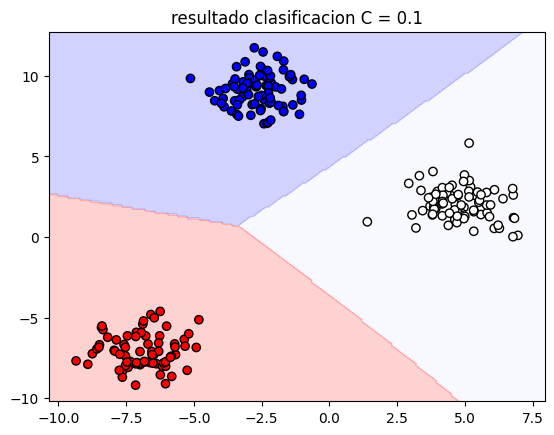

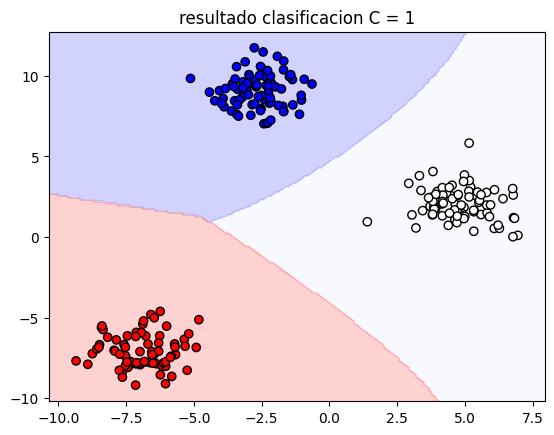

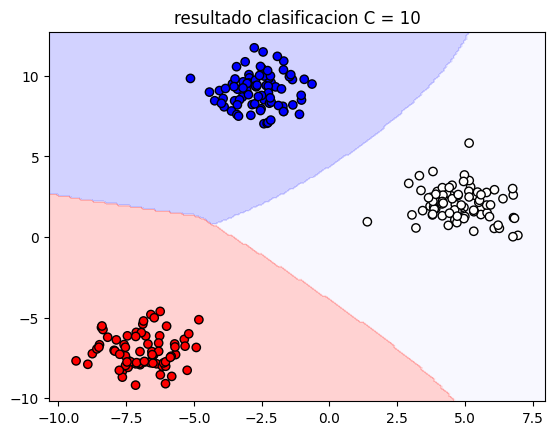

In [40]:
def plot_decision_boundary(model, X, y, ax, title):
    # crear malla
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap='bwr')
    ax.set_title(title)

# Dibujar para cada C
for i in range(len(C)):
    # llamar modelo 
    model = final_models_results[i]
    # inicializar fig y ax para plotear 
    fig,ax = plt.subplots()
    
    plot_decision_boundary(model, X_train, y_train,ax=ax, title=f"resultado clasificacion C = {C[i]}")

4. Replique el ejercicio anterior usando FashionMNIST

In [42]:
# Cell 1: Cargar Fashion MNIST (dos clases) y reducir a 2D con PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(int)

Categorías de Fashion MNIST:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


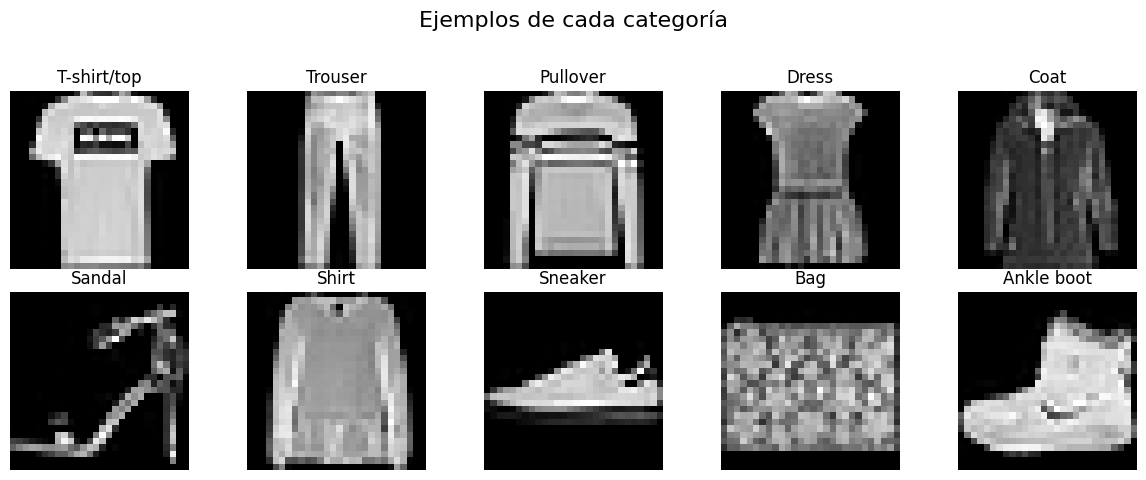

In [43]:
categories = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Categorías de Fashion MNIST:")
for i, cat in enumerate(categories):
    print(f"{i}: {cat}")

# 3) Plot de ejemplos (un ejemplar por clase)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Ejemplos de cada categoría", fontsize=16)

for idx, ax in enumerate(axes.flatten()):
    img = X[y == idx][0].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(categories[idx])
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

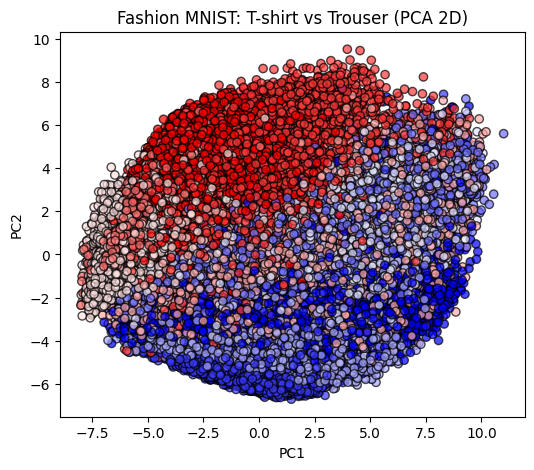

In [47]:
# Elegir categoria
# División train/val
# PCA a 2 componentes
from sklearn.decomposition import PCA

X_train,X_val,y_train,y_val = train_test_split(X,y,random_state=42,test_size=0.2)

pca = PCA(n_components=2, random_state=42)
X_train = pca.fit_transform(X_train / 255.0)
X_val   = pca.transform(X_val   / 255.0)

# Visualizar
plt.figure(figsize=(6,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr', edgecolor='k', alpha=0.7)
plt.title("Fashion MNIST: T-shirt vs Trouser (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [56]:
models = {
    'svm' : SVC
}

final_results = []

for C in [0.1, 1, 10]:
    svm = models['svm'](C=C)
    svm.fit(X_train, y_train)
    final_results.append(svm)
    print(f"C = {C} → train acc: {svm.score(X_train, y_train):.2f}, "
          f"val acc: {svm.score(X_val, y_val):.2f}")

C = 0.1 → train acc: 0.55, val acc: 0.55
C = 1 → train acc: 0.55, val acc: 0.55
C = 10 → train acc: 0.56, val acc: 0.56


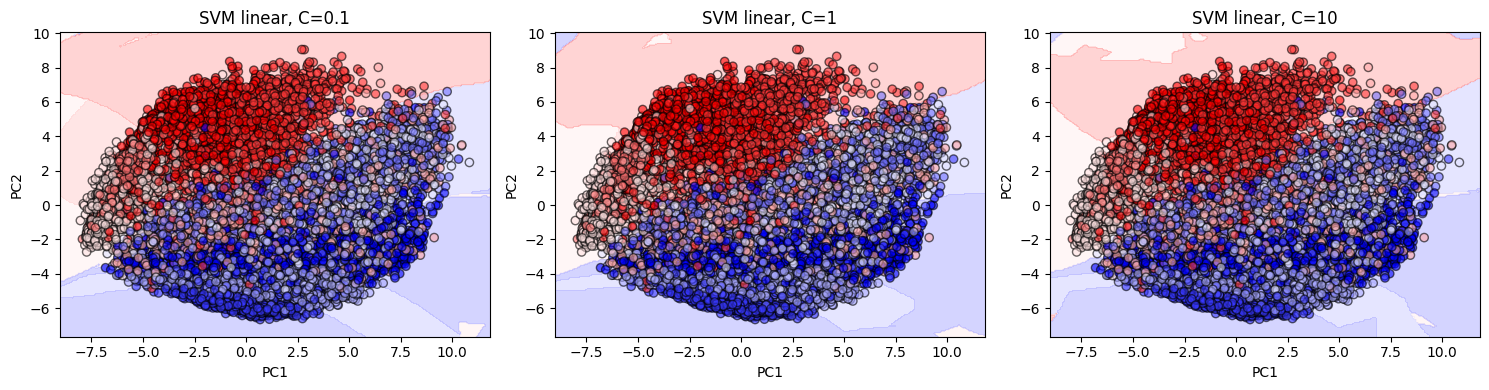

In [63]:
def plot_decision_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, C, model_entrenado in zip(axes,[0.1, 1, 10], final_results):
    # Llamamos a la función con el modelo, los datos de validación y el título.
    plot_decision_boundary(model_entrenado, X_val, y_val, ax, f"SVM linear, C={C}")

plt.tight_layout()
plt.show()

In [69]:
# Imprima C, numero de vectores de soporte y precision en validacion.
for i in range(0,3):
    model = final_results[i]
    # obtener el total de vectores de cada modelo 
    total_vectores = model.support_vectors_
    
    print(f"total de vectores : {total_vectores.shape}")

total de vectores : (48135, 2)
total de vectores : (46177, 2)
total de vectores : (45086, 2)
